# Test Motion Correction

## Imports

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm

from gulp2p.preproc.tiff import Tiff
from gulp2p.preproc.experiment import Experiment
from gulp2p.preproc import utils, imaging, behavior
from gulp2p.viz import plotting


config loaded


## Load Tiff

In [2]:
TIFF_PATH = Path(r"Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00004.tif")

In [3]:
tiff = Tiff(TIFF_PATH)

## Motion Correct

### Set Parameters

In [4]:
"""
numRefImg = the number of images to average for the reference image
locRefImg = the initial position in the stack to use for the reference
upsampleFactor = how much to upsample the image in order to shift the image by less than one pixel
stack = the stack to be registered
sigma = the sigma to use in Gaussian filtering
"""


num_ref_img = 50
upsample_factor = 20
sigma = 2

### Show begining middle and end of trial

In [5]:
def show_stack_across_time(tiff, num_segments=None, frame_segments=None):
    # Assume first dimension is frames.
    if frame_segments is not None:
        num_segments = len(frame_segments)
    if num_segments is None:
        # Show begining, middle, and end
        num_segments = 3
    if frame_segments is None:
        frame_segments = np.linspace(0, tiff.metadata['SizeT'], num_segments+1, dtype=int)
    else:
        num_segments = len(frame_segments) - 1

    fig, axs = plt.subplots(1, num_segments+1)
    mip_stack = tiff.get_mip_stack(motion_correct=False)
    for i in range(num_segments):
        stack_segment = mip_stack[frame_segments[i]:frame_segments[i+1]]
        mean_segment = np.mean(stack_segment,axis=0)
        axs[i].imshow(mean_segment)
        start_time = frame_segments[i] / tiff.metadata['volume_rate']
        end_time = frame_segments[i+1] / tiff.metadata['volume_rate']
        axs[i].set_title(f"{start_time:.0f} - {end_time:.0f}s")
        axs[i].set_axis_off()
    
    # Overlap them to look for motion
    mean_segments = []
    for i in range(num_segments):
        stack_segment = mip_stack[frame_segments[i]:frame_segments[i+1]]
        mean_segment = np.mean(stack_segment,axis=0)
        mean_segments.append(mean_segment)
    
    axs[-1].imshow(np.mean(mean_segments, axis=0))
    axs[-1].set_title("Overlapped\nsegments")
    axs[-1].set_axis_off()


In [6]:
# show_stack_across_time(tiff)

### Motion Correct

In [7]:
tiff.stack.shape

(2153, 7, 1, 256, 128)

In [8]:
tiff.metadata['SizeZ']

8

In [4]:
def motion_correct(tiff, num_ref_img=50, upsample_factor=20, sigma=2):
    stack = tiff.stack
    size_c = tiff.metadata['SizeC']

    # Specify the planes to use for the Maximum Intensity Projection (MIP)
    # slices = imaging.get_slices_from_stack()
    # Full tiff in one slice
    slices = [0, tiff.metadata['SizeZ']-1]

    # Calculate the MIP
    mip_stack = np.max(tiff.stack, axis=tiff.get_dim_axis('Z'))

    # Motion correct the MIP
    locRefImg = round(mip_stack.shape[0]/12)# the initial position in the stack to use for the reference. (~1/12 through the video)
    # [shift, stack_MC] = tifMotionCorrect(numRefImg, locRefImg, upsampleFactor, np.squeeze(stack_MIP[:,0,:,:]), sigma)

    if size_c == 1:
        [shift, stack_MC] = imaging.tif_motion_correct(num_ref_img, locRefImg, upsample_factor, np.squeeze(mip_stack), sigma)
    else:
        [shift, stack_MC] = imaging.tif_motion_correct(num_ref_img, locRefImg, upsample_factor, np.squeeze(mip_stack[:,0,:,:]), sigma)
    return [shift, stack_MC]

c:\Users\ahshenas\Anaconda3\envs\gulp2p\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [10]:
# mip_stack = tiff.get_mip_stack()
# stack_mc = motion_correct(tiff)

# fig, axs = plt.subplots(1, 2)
# axs[0].imshow(np.mean(mip_stack, axis=0))
# axs[1].imshow(np.mean(stack_mc, axis=0))

# axs[0].set_title("Raw MIP")
# axs[1].set_title("Motion Corrected MIP")


## Parameter Sweep:

In [11]:
"""
numRefImg = the number of images to average for the reference image
locRefImg = the initial position in the stack to use for the reference
upsampleFactor = how much to upsample the image in order to shift the image by less than one pixel
stack = the stack to be registered
sigma = the sigma to use in Gaussian filtering
"""

num_ref_imgs = [1, 2, 5, 10, 200]
upsample_factors = [5, 10, 20, 30, 50, 200]
sigmas = [1, 1.25, 1.5, 2, 2.5, 3]

In [12]:
OUTPUT_FOLDER = (r"Z:\GULP\results\motion_correction_parameter_sweep")

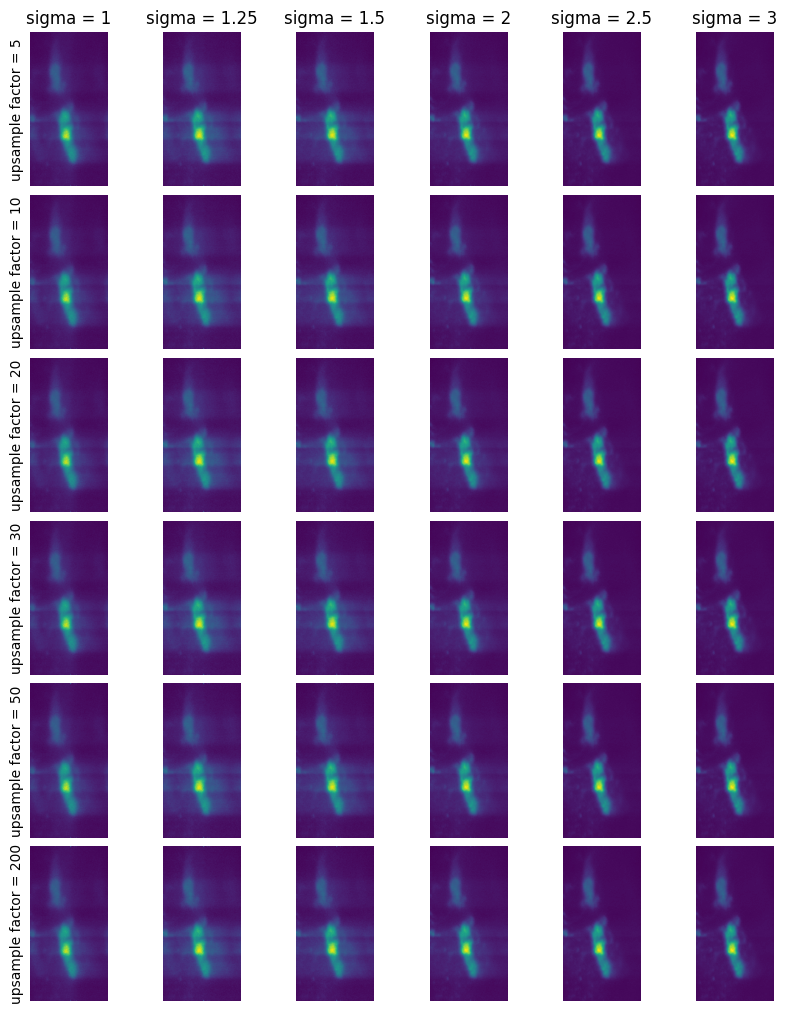

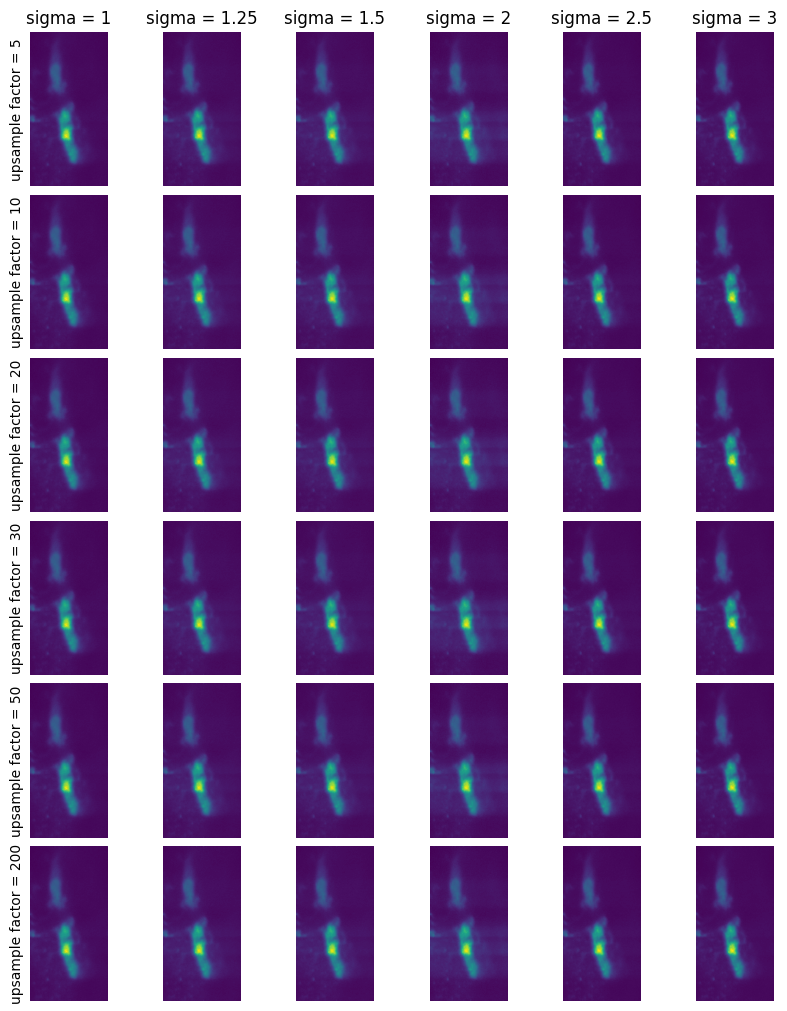

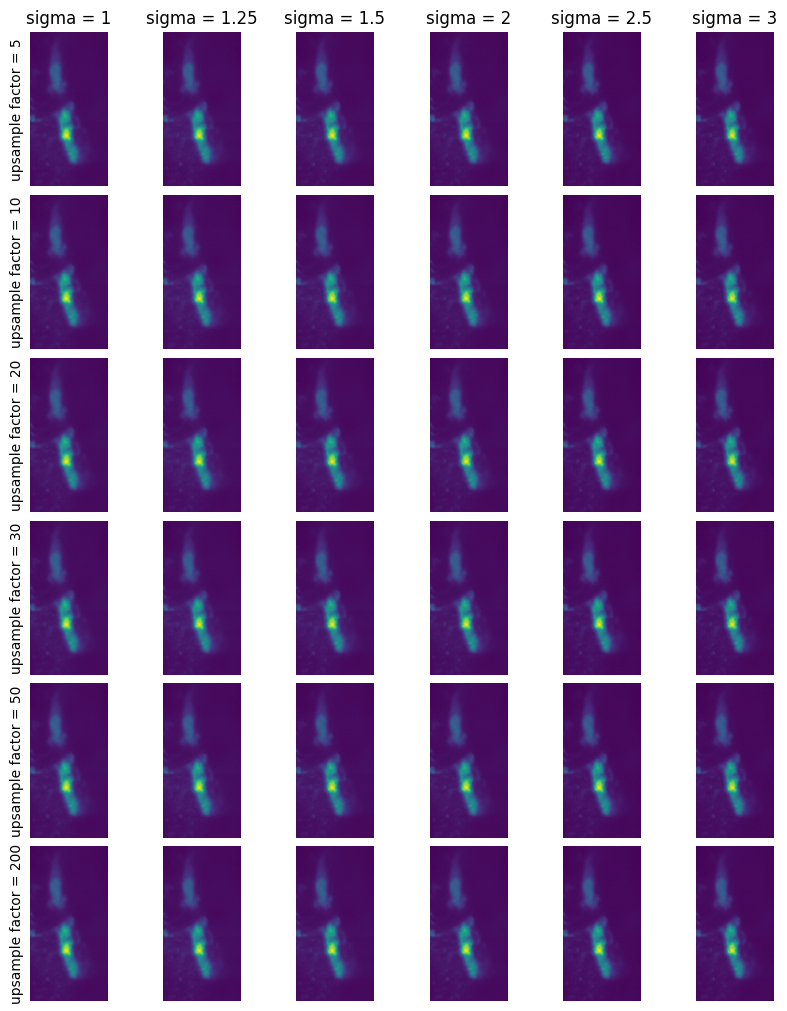

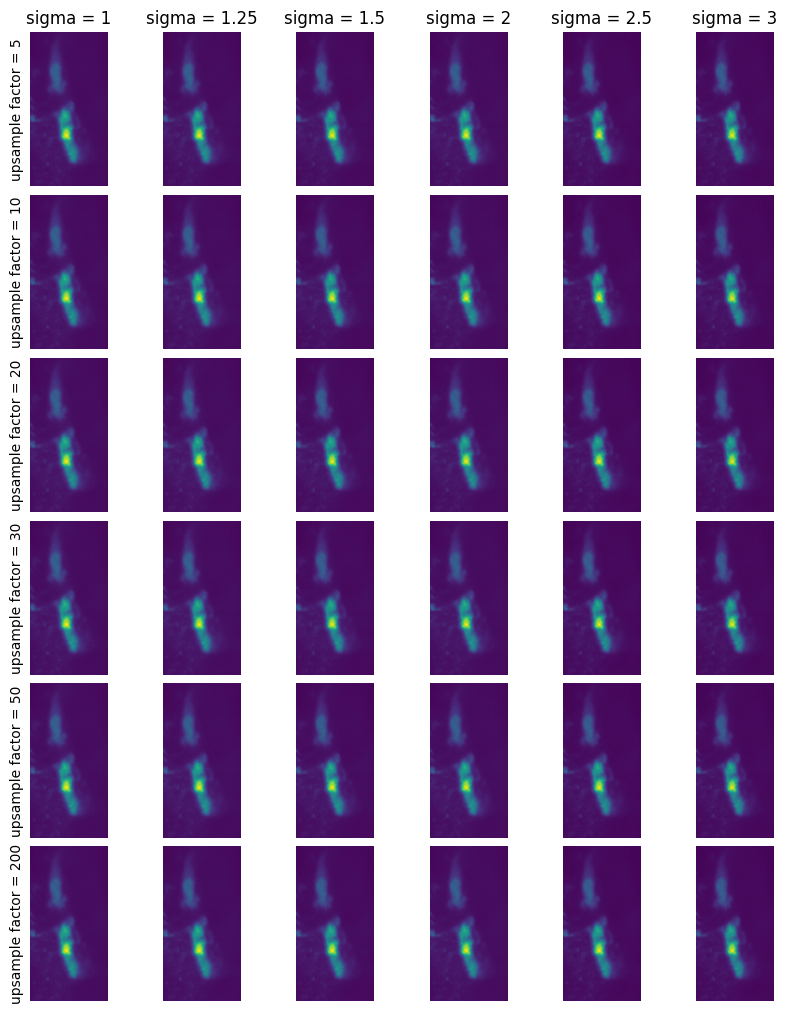

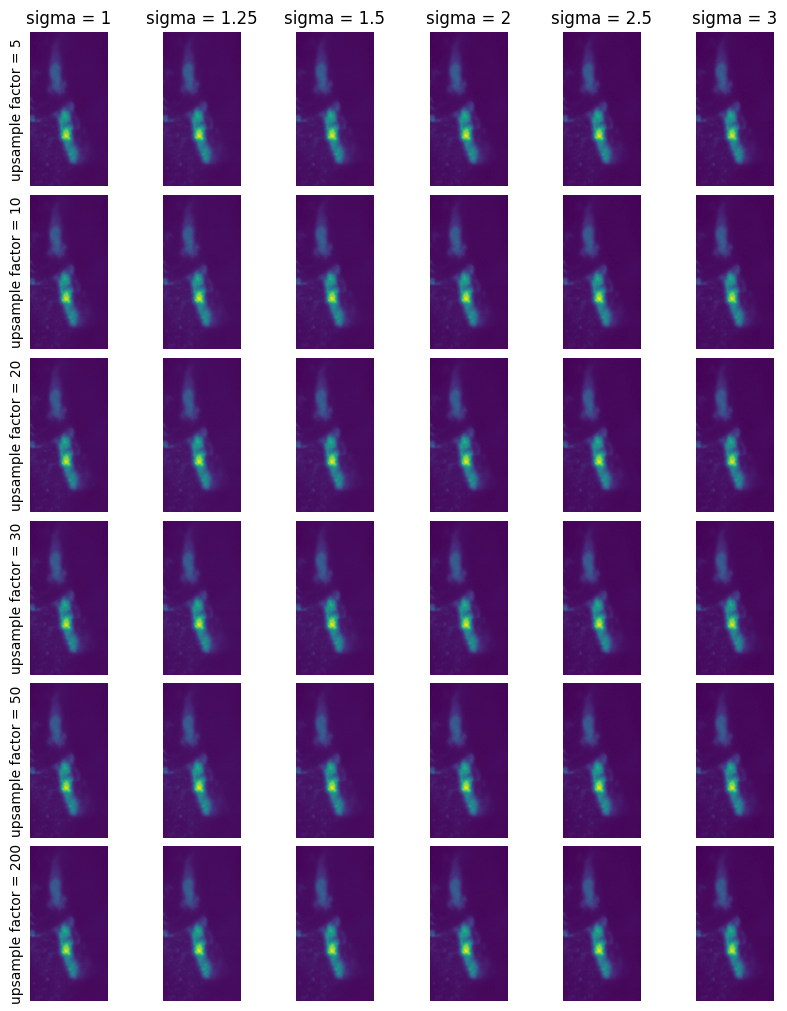

In [13]:
for i, num_ref_img in enumerate(num_ref_imgs):
    fig, axs = plt.subplots(len(upsample_factors), len(sigmas),
                            figsize=(8,10),
                            layout="constrained")
    for j, upsample_factor in enumerate(upsample_factors):
        for k, sigma in enumerate(sigmas):
            # Motion Correct
            stack_mc = motion_correct(tiff, num_ref_img, upsample_factor, sigma)
            # Plot
            axs[j,k].imshow(np.mean(stack_mc,axis=0))

            # Plot Aesthetics
            axs[j,k].set_xticks([])
            axs[j,k].set_yticks([])
            for loc, spine in axs[j,k].spines.items():
                spine.set_visible(False)
            if k == 0:
                axs[j,0].set_ylabel(f"upsample factor = {upsample_factor}")
            if j == 0:
                axs[0,k].set_title(f"sigma = {sigma}")
    fig.savefig(Path(OUTPUT_FOLDER, f"{num_ref_img}_ref_img_param_sweep.png"), dpi=600*2)


## Check Motion Correction in Napari

In [5]:
import napari

In [34]:
TIFF_PATH = Path(r"Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00004.tif")
tiff = Tiff(TIFF_PATH)

In [35]:
num_ref_imgs = [1, 2, 5, 10, 200]
upsample_factors = [5, 10, 20, 30, 50, 200]
sigmas = [1, 1.25, 1.5, 2, 2.5, 3]

In [36]:
num_ref_img = 50
upsample_factor = 20
sigma = 3

In [37]:
[shift, stack_mc] = motion_correct(tiff, num_ref_img, upsample_factor, sigma)

In [38]:
def plot_shift(shift):
    shift_y, shift_x = shift
    ax = plt.subplot()
    ax.plot(shift_x, label="x", alpha=0.5)
    ax.plot(shift_y, label="y", alpha=0.5)
    ax.legend()

In [39]:
print(f"min: {np.amin(shift, axis=1)}")
print(f"index: {np.argmin(shift, axis=1)}")
print()
print(f"max: {np.amax(shift, axis=1)}")
print(f"index: {np.argmax(shift, axis=1)}")


min: [-95.25 -59.6 ]
index: [1388  256]

max: [91.15 63.75]
index: [966 147]


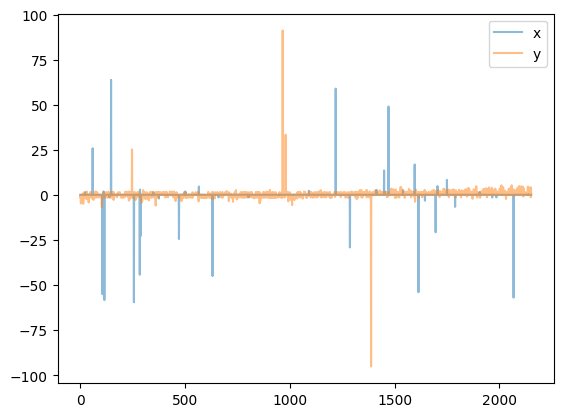

In [40]:
plot_shift(shift)

In [41]:
def show_in_napari(stacks, names=None):
    viewer = napari.Viewer()
    for index, stack in enumerate(stacks):
        viewer.add_image(stack,
                         colormap='viridis',
                         gamma=0.4,
                         name=names[index])
    napari.run()

In [42]:
# show_in_napari([np.mean(stack_mc, axis=0),
#                 tiff.get_mip_stack(),
#                 stack_mc],
#                 ["Motion Corrected Mean",
#                  "Raw MIP",
#                  "Motion Corrected MIP"])

### Try shifting original stack by shift from motion correct

In [43]:
def shift_image(stack, shift):
    # Given an image of shape [T,Y,X] (eg: 200,256,128 = 200 frames, height x width = 256 x 128)
    shifted_stack = stack.copy()
    print(shifted_stack.shape)
    for index, frame in enumerate(stack):
        frame_shift = np.array(np.flip(shift[:, index]), dtype=int)
        if index == 635:
            print(frame_shift)
        shifted_stack[index] = np.roll(frame, [1, 1] * frame_shift, axis=(-2, -1))
    return shifted_stack

In [44]:
custom_shift = shift_image(tiff.get_mip_stack(), shift)

(2153, 256, 128)
[0 1]


In [45]:
shift.shape

(2, 2153)

In [46]:
tiff.stack.shape

(2153, 7, 1, 256, 128)

In [47]:
show_in_napari([tiff.stack,
                np.mean(stack_mc, axis=0),
                tiff.get_mip_stack(motion_correct=False),
                stack_mc,
                custom_shift,],
                ["full stack",
                 "Motion Corrected Mean",
                 "Raw MIP",
                 "Motion Corrected MIP",
                 "Custom Shift",])

## Try CaImAn

### Imports

In [1]:
import cv2
# from IPython import get_ipython
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from gulp2p.preproc.tiff import Tiff
import os

try:
    cv2.setNumThreads(0)
except:
    pass

import caiman as cm
from caiman.motion_correction import MotionCorrect

config loaded


### Select tiff

In [2]:
tiff = Tiff(r"Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00004.tif")

In [3]:
m_orig = cm.movie(tiff.get_mip_stack())
downsample_ratio = .2  # motion can be perceived better when downsampling in time

### Set params

In [4]:
max_shifts = (6, 6)  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
strides =  (48, 48)  # create a new patch every x pixels for pw-rigid correction
overlaps = (24, 24)  # overlap between patches (size of patch strides+overlaps)
max_deviation_rigid = 3   # maximum deviation allowed for patch with respect to rigid shifts
pw_rigid = True  # flag for performing rigid or piecewise rigid motion correction
shifts_opencv = True  # flag for correcting motion using bicubic interpolation (otherwise FFT interpolation is used)
border_nan = 'min'  # replicate values along the boundary (if True, fill in with NaN) [True, False 'min', 'copy']

### Start a cluster

In [5]:
if 'dview' in locals():
    cm.stop_server(dview=dview)
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=None, single_thread=False)

### Create motion correction object

In [6]:
# create a motion correction object
mc = MotionCorrect(tiff.get_mip_stack(), dview=dview, max_shifts=max_shifts,
                  strides=strides, overlaps=overlaps,
                  max_deviation_rigid=max_deviation_rigid, 
                  shifts_opencv=shifts_opencv, nonneg_movie=True,
                  border_nan=border_nan)

In [7]:
import tempfile
tempdir = tempfile.TemporaryDirectory()
os.environ['CAIMAN_NEW_TEMPFILE'] = "True"
os.environ['CAIMAN_TEMP'] = tempdir.name

### Motion correct

In [8]:
mc.mmap_file = Path(tempdir.name, "mmap_file")

In [9]:
%%capture
# correct for rigid motion correction and save the file (in memory mapped form)
mc.motion_correct(save_movie=True)

In [10]:
# load motion corrected movie
m_rig = cm.load(mc.mmap_file)


100%|██████████| 1/1 [00:00<00:00,  3.95it/s]


In [11]:
tempdir.cleanup()
del os.environ['CAIMAN_NEW_TEMPFILE']
del os.environ['CAIMAN_TEMP']
Path("tmp_mov_mot_corr.hdf5").unlink()

In [12]:
bord_px_rig = np.ceil(np.max(mc.shifts_rig)).astype(int)

In [12]:
# #%% inspect movie
m_rig.resize(1, 1, downsample_ratio).play(
    q_max=99.5, fr=30, magnification=2, bord_px = 0*bord_px_rig) # press q to exit

In [13]:
# Compare movies
cm.concatenate([m_orig.resize(1, 1, downsample_ratio) - mc.min_mov*mc.nonneg_movie,
                m_rig.resize(1, 1, downsample_ratio)],
                axis=2).play(fr=60, q_max=99.5, magnification=2, bord_px=bord_px_rig)

### View shifts

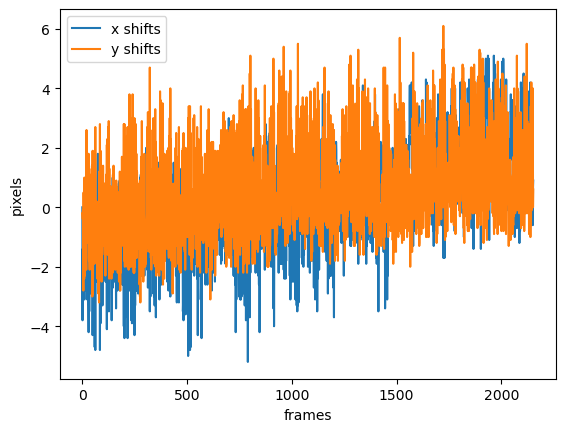

In [11]:
#%% plot rigid shifts
plt.close()
plt.figure()
plt.plot(mc.shifts_rig)
plt.legend(['x shifts','y shifts'])
plt.xlabel('frames')
plt.ylabel('pixels');

### Stop the cluster

In [10]:
cm.stop_server(dview=dview) # stop the server

## Test function

In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import caiman as cm
from gulp2p.preproc.imaging import motion_correct
from gulp2p.preproc.tiff import Tiff

In [16]:
# tiff_path = Path(r"C:\Users\ahshenas\caiman_data\example_movies\MAX_20240125_DR019xiGluSnFR_Fly02_00004.tif")
tiff_path = Path(r"Z:/2PImaging/Kerstin/MIMS/20231207/20231207_DR019xiGluSnFr_Fly2_00003.tif")

In [17]:
tiff = Tiff(tiff_path)

In [18]:
mc_params = {
    'strides': (48, 48),       # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
    'overlaps': (24, 24),      # create a new patch every x pixels for pw-rigid correction
    'max_shifts': (12, 12),      # overlap between patches (size of patch strides+overlaps)
    'max_deviation_rigid': 3,  # maximum deviation allowed for patch with respect to rigid shifts
    'pw_rigid': False,         # flag for performing rigid or piecewise rigid motion correction
    'shifts_opencv': True,     # flag for correcting motion using bicubic interpolation (otherwise FFT interpolation is used)
    'border_nan': 'min',       # replicate values along the boundary (if True, fill in with NaN) [True, False 'min', 'copy']
    }

In [19]:
print(tiff.metadata['dimension_order'])
print(tiff.stack.shape)

TZCYX


KeyboardInterrupt: 

100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


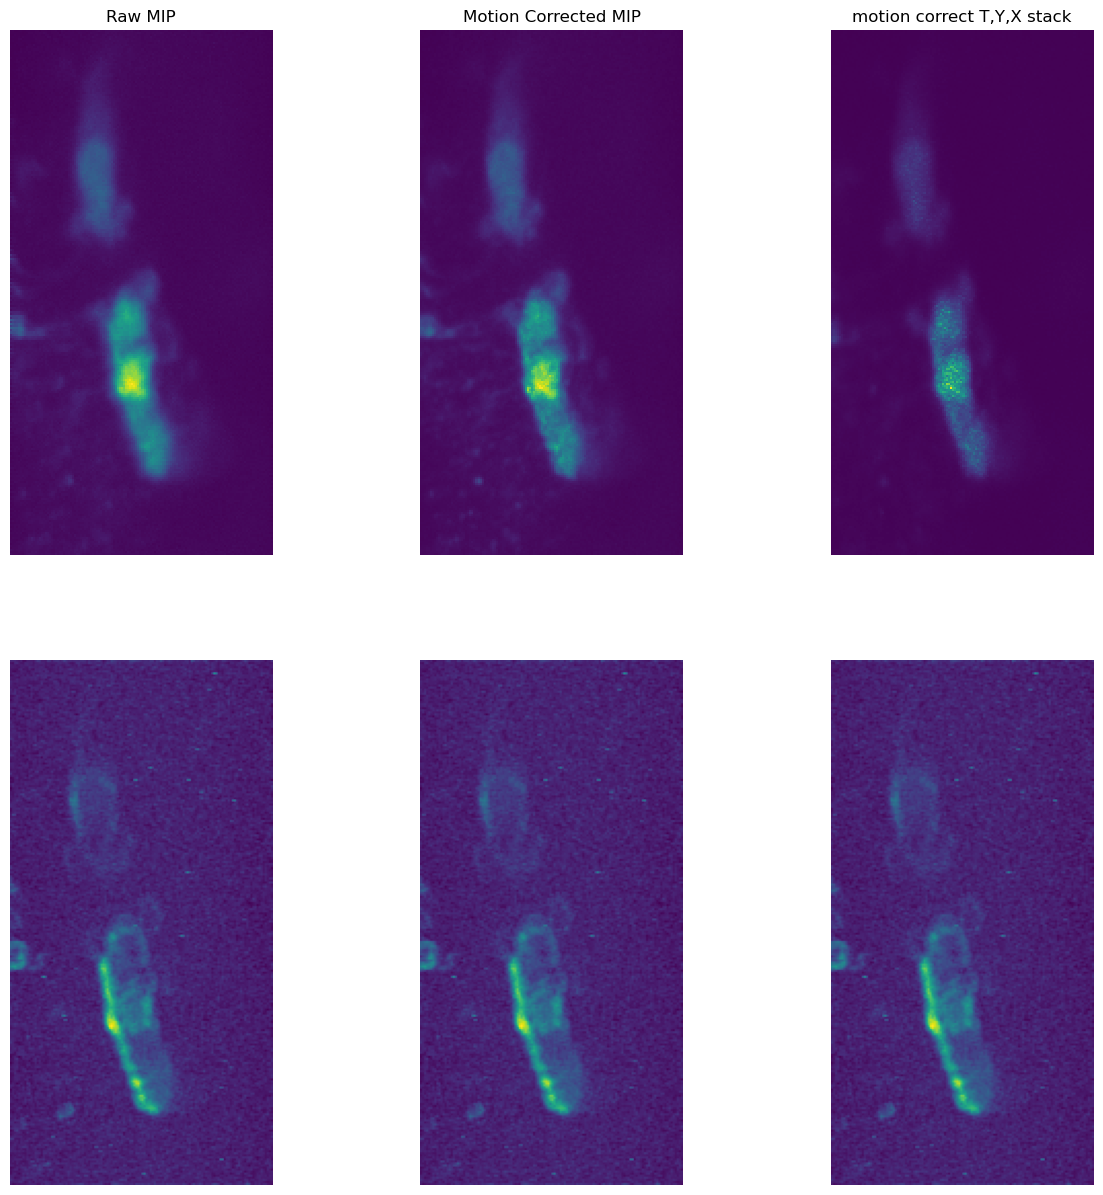

In [ ]:
fig, axs = plt.subplots(2, 3,
                        figsize=(15,15))
# Raw MIP
mip_stack = tiff.get_mip_stack()
axs[0,0].imshow(mip_stack.mean(axis=0), interpolation='none')
axs[0,0].set_title("Raw MIP")

# Motion corrected MIP
stack_mc = motion_correct(mip_stack)
axs[0,1].imshow(stack_mc.mean(axis=0), interpolation='none')
axs[0,1].set_title("Motion Corrected MIP")

# motion correct T,Y,X stack
stack_mc_tyx = motion_correct(tiff.stack.reshape(tiff.metadata['SizeT']*(tiff.metadata['SizeZ']),
                                                 tiff.metadata['SizeY'],
                                                 tiff.metadata['SizeX']))
axs[0,2].imshow(stack_mc_tyx.mean(axis=0), interpolation='none')
axs[0,2].set_title("motion correct T,Y,X stack")


m_mip_stack = cm.movie(mip_stack)
m_stack_mc = cm.movie(mip_stack)
m_stack_mc_tyx = cm.movie(mip_stack)
axs[1,0].imshow(m_mip_stack.local_correlations(eight_neighbours=True, swap_dim=False))
axs[1,1].imshow(m_stack_mc.local_correlations(eight_neighbours=True, swap_dim=False))
axs[1,2].imshow(m_stack_mc_tyx.local_correlations(eight_neighbours=True, swap_dim=False))


for i in range(2):
    for j in range(3):
        axs[i,j].set_axis_off()

In [ ]:
downsample_ratio = 1
cm.concatenate([m_mip_stack.resize(1, 1, downsample_ratio),
                m_stack_mc.resize(1, 1, downsample_ratio),
                m_stack_mc_tyx.resize(1, 1, downsample_ratio)],
                axis=2).play(fr=20, q_max=99.5, magnification=2)

In [ ]:
import napari
from gulp2p.config import CONFIG_DICT
viewer = napari.Viewer()
viewer.add_image(mip_stack, name="original stack",
                 colormap=CONFIG_DICT['napari_colormap'],
                 gamma=CONFIG_DICT['napari_gamma'])
viewer.add_image(stack_mc, name="motion corrected stack",
                 colormap=CONFIG_DICT['napari_colormap'],
                 gamma=CONFIG_DICT['napari_gamma'])
viewer.add_image(stack_indiv_mc, name="individual slice motion corrected stack",
                 colormap=CONFIG_DICT['napari_colormap'],
                 gamma=CONFIG_DICT['napari_gamma'])
viewer.add_image(stack_indiv_mc.max(axis=1), name="individual slice motion corrected stack mip",
                 colormap=CONFIG_DICT['napari_colormap'],
                 gamma=CONFIG_DICT['napari_gamma'])
napari.run()